In [ ]:
import sys

!{sys.executable} -m pip uninstall -y transformers
!{sys.executable} -m pip install transformers==5.6.2 accelerate safetensors
!{sys.executable} -m pip show transformers

In [132]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "Qwen/Qwen3.5-0.8B"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
  model_name,
  torch_dtype=torch.float16,
  device_map="auto",
  offload_folder="offload"
)

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

In [ ]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
  load_in_4_bit=True,
  bnb_4bit_compute_dtype=torch.float16,
  bnb_4bit_quant_type="nf4"
)

model_quantization = AutoModelForCausalLM.from_pretrained(
  model_name,
  quantization_config=bnb_config,
  attn_implementation="flash_attention_2",
  device_map={"": 0},
  offload_folder="offload"
)

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

In [134]:
from peft import prepare_model_for_kbit_training

model_quantization = prepare_model_for_kbit_training(model_quantization)

In [ ]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
  r=8,
  lora_alpha=16,
  target_modules=["q_proj", "v_proj"],
  layers_to_transform=list(range(19, 24)), #testing - top 20% layers unfrozen
  lora_dropout=0.05,
  bias="none",
  task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

In [136]:
from peft import get_peft_model

model_quantization = get_peft_model(model_quantization, lora_config)

In [137]:
import numpy as np
import pandas as pd
import os

path = os.path.join(os.getcwd(), "dataset/questions.csv")

df = pd.read_csv(path)

print(df.head())

   id  qid1  qid2                                          question1  \
0   0     1     2  What is the step by step guide to invest in sh...   
1   1     3     4  What is the story of Kohinoor (Koh-i-Noor) Dia...   
2   2     5     6  How can I increase the speed of my internet co...   
3   3     7     8  Why am I mentally very lonely? How can I solve...   
4   4     9    10  Which one dissolve in water quikly sugar, salt...   

                                           question2  is_duplicate  
0  What is the step by step guide to invest in sh...             0  
1  What would happen if the Indian government sto...             0  
2  How can Internet speed be increased by hacking...             0  
3  Find the remainder when [math]23^{24}[/math] i...             0  
4            Which fish would survive in salt water?             0  


In [138]:
def format_question_pair_into_dataset(row):
  
  answer = "Yes" if row['is_duplicate'] else "No"
  
  text = f"""###Instruction:
  Determine wheter the following two questions are duplicates.
  
  ### Question 1:
  {row['question1']}
  
  ### Question 2:
  {row['question2']}
  
  ### Answer:
  {answer}
  """
  
  return text

df["text"] = df.apply(format_question_pair_into_dataset, axis=1)

In [139]:
print(df["text"].iloc[0])

###Instruction:
  Determine wheter the following two questions are duplicates.
  
  ### Question 1:
  What is the step by step guide to invest in share market in india?
  
  ### Question 2:
  What is the step by step guide to invest in share market?
  
  ### Answer:
  No
  


In [ ]:
from datasets import Dataset

# dataset = Dataset.from_pandas(df[["text"]])
dataset = Dataset.from_pandas(df)

In [141]:
def get_length(example):
    return {"length": len(tokenizer(example["text"])["input_ids"])}

length_dataset = dataset.map(get_length)

Map:   0%|          | 0/404351 [00:00<?, ? examples/s]

In [142]:
import numpy as np

lengths = np.array(length_dataset["length"])

p99 = int(np.percentile(lengths, 99))

print("99th percentile:", p99)
print("max length:", lengths.max())
print("median:", np.median(lengths))


99th percentile: 117
max length: 363
median: 70.0


In [143]:
def tokenize(example):

  tokens = tokenizer(
    example["text"],
    truncation=True,
    padding="max_length",
    max_length=p99
  )

  tokens["labels"] = tokens["input_ids"].copy()

  return tokens


tokenized_dataset = dataset.map(
    tokenize,
    batched=True
)


Map:   0%|          | 0/404351 [00:00<?, ? examples/s]

In [144]:
print(tokenized_dataset[0]["text"],"\n")
print(tokenized_dataset[0]["input_ids"],"\n")
print(tokenized_dataset[0]["attention_mask"],"\n")
print(tokenized_dataset[0]["labels"])

###Instruction:
  Determine wheter the following two questions are duplicates.
  
  ### Question 1:
  What is the step by step guide to invest in share market in india?
  
  ### Question 2:
  What is the step by step guide to invest in share market?
  
  ### Answer:
  No
   

[13962, 16174, 25, 198, 220, 28924, 412, 1356, 279, 2614, 1330, 4602, 513, 40922, 13, 198, 2228, 220, 16112, 15380, 220, 16, 25, 198, 220, 3437, 369, 279, 2923, 539, 2923, 8214, 310, 2638, 303, 4191, 2981, 303, 26813, 30, 198, 2228, 220, 16112, 15380, 220, 17, 25, 198, 220, 3437, 369, 279, 2923, 539, 2923, 8214, 310, 2638, 303, 4191, 2981, 30, 198, 2228, 220, 16112, 21134, 25, 198, 220, 2233, 198, 256, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 248044, 24804

In [145]:
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

In [146]:
dataset_split = tokenized_dataset.train_test_split(test_size=0.1, seed=42)

train_dataset = dataset_split["train"]
test_dataset = dataset_split["test"]

print(train_dataset, "\n")
print(test_dataset)

Dataset({
    features: ['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 363915
}) 

Dataset({
    features: ['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 40436
})


In [147]:
train_dataset = train_dataset.remove_columns(["id", "qid1", "qid2", "question1", "question2", "is_duplicate"])
#test_dataset = test_dataset.remove_columns(["id", "qid1", "qid2"])

In [ ]:
print(train_dataset, "\n")

In [148]:
model_quantization.print_trainable_parameters()

trainable params: 106,496 || all params: 752,499,520 || trainable%: 0.0142


In [149]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

checkpoint_path = os.path.join(os.getcwd(), "qwen-lora/checkpoint-11374/")

model_quantization.gradient_checkpointing_enable()

data_collator = DataCollatorForLanguageModeling(
  tokenizer=tokenizer,
  mlm=False
)

training_args = TrainingArguments(
  output_dir="./qwen-lora",
  per_device_train_batch_size=16,
  gradient_accumulation_steps=4,
  fp16=True,
  gradient_checkpointing=False,
  logging_steps=50,
  save_steps=500,
  remove_unused_columns=False,
  num_train_epochs=2 
)



trainer = Trainer(
  model=model_quantization,
  args=training_args,
  train_dataset=train_dataset,
  data_collator=data_collator
)

trainer.train(resume_from_checkpoint=checkpoint_path)

Step,Training Loss


TrainOutput(global_step=11374, training_loss=0.0, metrics={'train_runtime': 0.0023, 'train_samples_per_second': 319625199.489, 'train_steps_per_second': 4994871.081, 'total_flos': 2.545587809953344e+17, 'train_loss': 0.0, 'epoch': 2.0})

In [150]:
def create_test_prompt(row):
  text = f"""###Instruction:
  Determine wheter the following two questions are duplicates.
  
  ### Question 1:
  {row['question1']}
  
  ### Question 2:
  {row['question2']}
  
  ### Answer:
  """
  return text

In [151]:
sample = df.iloc[0]

prompt = create_test_prompt(sample)

inputs = tokenizer(prompt, return_tensors="pt").to(model_quantization.device)

outputs = model_quantization.generate(
    **inputs,
    max_new_tokens=1,
    temperature=0.0
)

prediction = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(prediction)

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


###Instruction:
  Determine wheter the following two questions are duplicates.
  
  ### Question 1:
  What is the step by step guide to invest in share market in india?
  
  ### Question 2:
  What is the step by step guide to invest in share market?
  
  ### Answer:
   Yes


In [152]:
print(test_dataset.column_names)

['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate', 'input_ids', 'attention_mask', 'labels']


In [ ]:
### DEBUGGING CELL to see top 5 output tokens for a given input prompt ###

# Pick one batch and see the top predicted token

# inputs = tokenizer(prompts[0:1], return_tensors="pt").to(model_quantization.device)
# with torch.no_grad():
#     outputs = model_quantization(**inputs)
#     next_token_logits = outputs.logits[:, -1, :]
#     top_tokens = torch.topk(next_token_logits, 5).indices[0]
    
#     print("Top 5 predicted tokens:")
#     for token_id in top_tokens:
#         print(f"Token: '{tokenizer.decode([token_id])}' | ID: {token_id}")

Top 5 predicted tokens:
Token: ' No' | ID: 2233
Token: ' Yes' | ID: 7179
Token: ' There' | ID: 2532
Token: ' If' | ID: 1368
Token: ' The' | ID: 561


In [ ]:
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
import torch

no_token_id = 2233
yes_token_id = 7179

probabilities = []
labels = []

batch_size = 16
test_loader = DataLoader(test_dataset, batch_size=batch_size)
tokenizer.padding_side = 'left'

model_quantization.eval()
with torch.no_grad():
    for batch in tqdm(test_loader):
        
        batch_len = len(batch['question1'])
        prompts = [
            create_test_prompt({k: batch[k][i] for k in batch}) 
            for i in range(batch_len)
        ]
        
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(model_quantization.device)
        
        outputs = model_quantization.generate(
            **inputs,
            max_new_tokens=1,
            return_dict_in_generate=True,
            output_scores=True,
            pad_token_id=tokenizer.eos_token_id
        )

        # Logits for single generated token
        next_token_logits = outputs.scores[0]

        # Slicing the logits for the EXACT ' Yes' and ' No' neurons
        # Index 0 =' Yes', Index 1 = ' No'
        relevant_logits = next_token_logits[:, [yes_token_id, no_token_id]]
        probs = F.softmax(relevant_logits, dim=-1)
        
        # Take Probability of ' Yes' (Index 0)
        probabilities.extend(probs[:, 0].cpu().numpy())
        labels.extend(batch["is_duplicate"])

probabilities = np.array(probabilities)
labels = np.array(labels)


  0%|          | 0/2528 [00:00<?, ?it/s]

In [187]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss

y_pred_hard = (probabilities > 0.5).astype(int)

final_results = {
    "Accuracy": accuracy_score(labels, y_pred_hard),
    "F1 Score": f1_score(labels, y_pred_hard),
    "AUC": roc_auc_score(labels, probabilities),
    "Log Loss": log_loss(labels, probabilities)
}

for name, value in final_results.items():
    print(f"{name}: {value:.4f}")

Accuracy: 0.7501
F1 Score: 0.7407
AUC: 0.9051
Log Loss: 0.5329


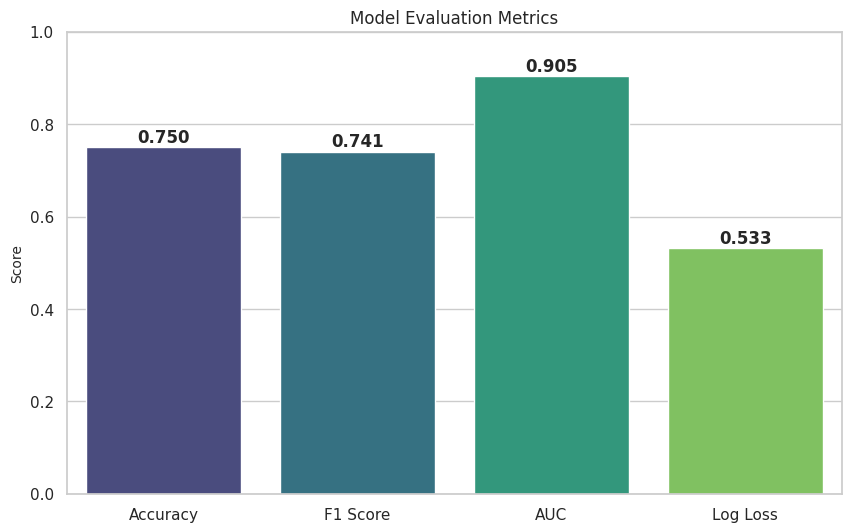

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metrics(metrics_dict):
  
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    names = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    
    ax = sns.barplot(x=names, y=values, palette="viridis", hue=names)
    
    plt.ylim(0,1)
    plt.title("Model Evaluation Metrics", fontsize=12)
    plt.ylabel("Score", fontsize=10)
    
    for i, v in enumerate(values):
        ax.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

    plt.show()

plot_metrics(final_results)

In [175]:
import pandas as pd

results_data = {
    "question1": test_dataset["question1"],
    "question2": test_dataset["question2"],
    "actual_label": labels,
    "predicted_label": y_pred_hard,
    "yes_probability": probabilities
}

df_results = pd.DataFrame(results_data)

df_results["is_correct"] = df_results["actual_label"] == df_results["predicted_label"]

df_results.to_csv("qwen_qqp_results.csv", index=False)

print(f"Saved {len(df_results)} rows to qwen_qqp_results.csv")

Saved 40436 rows to qwen_qqp_results.csv
